MEMBER 3: RANDOM FOREST & SUPPORT VECTOR MACHINE (SVM)
Current working directory: C:\Users\ASUS\Downloads\assignment (1)
 Created necessary folders

STEP 1: LOADING PREPROCESSED DATA
 Loaded dataset successfully!
   Shape: (5110, 13)
   Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'age_group', 'bmi_category']
 Loaded feature list
 Loaded scaler from Member 2

First 5 rows of preprocessed data:
   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          2   
1       0  61.0             0              0             1          3   
2       1  80.0             0              1             1          2   
3       0  49.0             0              0             1          2   
4       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level   bmi  sm

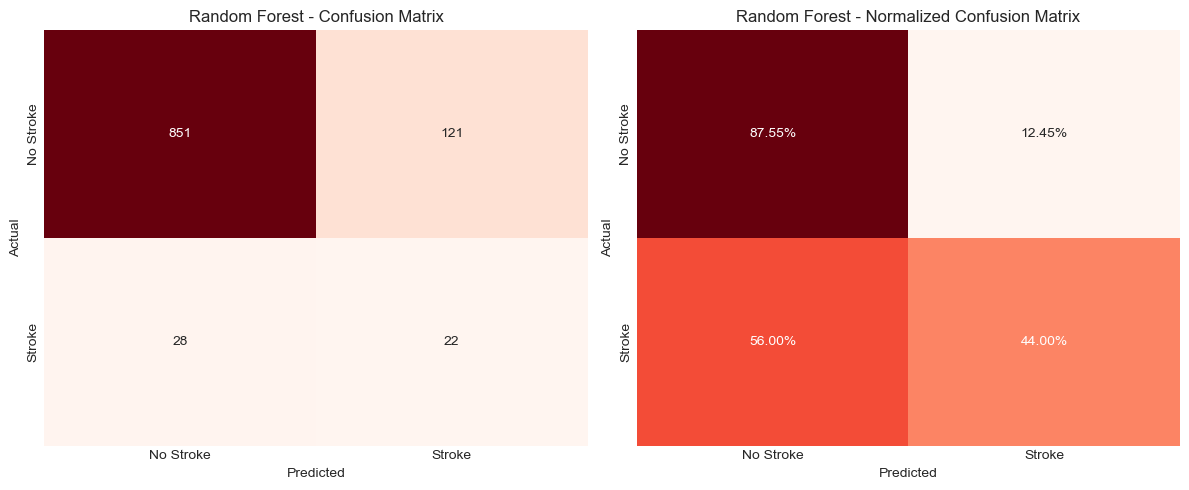

 Saved confusion matrices to 'results/rf_confusion_matrix.png'

----------------------------------------
Cross-Validation (5-Fold)...
----------------------------------------


In [ ]:
# ============================================
# MEMBER 3: RANDOM FOREST & SUPPORT VECTOR MACHINE (SVM)
# ============================================
# This notebook implements two advanced supervised learning algorithms:
# 1. Random Forest Classifier - Ensemble of decision trees for robust prediction
# 2. Support Vector Machine (SVM) - Finds optimal hyperplane for classification

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score, recall_score, 
                             precision_score, matthews_corrcoef)
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CREATE NECESSARY FOLDERS
# ============================================

os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("="*70)
print("MEMBER 3: RANDOM FOREST & SUPPORT VECTOR MACHINE (SVM)")
print("="*70)
print(f"Current working directory: {os.getcwd()}")
print(" Created necessary folders")

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================
# STEP 1: LOAD PREPROCESSED DATA (from Member 1)
# ============================================

print("\n" + "="*50)
print("STEP 1: LOADING PREPROCESSED DATA")
print("="*50)

try:
    df = pd.read_csv('data/stroke_data_preprocessed.csv')
    print(f" Loaded dataset successfully!")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")
    
    # Load feature list
    with open('data/feature_list.pkl', 'rb') as f:
        feature_list = pickle.load(f)
    print(f" Loaded feature list")
    
    # Load scaler from Member 2
    with open('models/scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    print(f" Loaded scaler from Member 2")
    
except FileNotFoundError as e:
    print(f" Error: {e}")
    print("   Please ensure Member 1 and Member 2 have run their notebooks first!")
    print("   Required files: data/stroke_data_preprocessed.csv, models/scaler.pkl")
    raise

print(f"\nFirst 5 rows of preprocessed data:")
print(df.head())

# ============================================
# STEP 2: DATA VERIFICATION
# ============================================

print("\n" + "="*50)
print("STEP 2: DATA VERIFICATION")
print("="*50)

print(f"\nTarget Variable Distribution:")
print(df['stroke'].value_counts())
print(f"Stroke percentage: {df['stroke'].mean()*100:.2f}%")

# Check for any missing values
print(f"\nMissing values check: {df.isnull().sum().sum()} missing values (should be 0)")

# ============================================
# STEP 3: SEPARATE FEATURES AND TARGET
# ============================================

print("\n" + "="*50)
print("STEP 3: SEPARATING FEATURES AND TARGET")
print("="*50)

X = df.drop('stroke', axis=1)
y = df['stroke']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Identify numerical features (needed for scaling)
numerical_features = ['age', 'avg_glucose_level', 'bmi']
print(f"\nNumerical features to scale: {numerical_features}")

# ============================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*50)
print("STEP 4: TRAIN-TEST SPLIT")
print("="*50)

# Split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Class 0 (No Stroke): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Class 1 (Stroke): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

# ============================================
# STEP 5: HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================

print("\n" + "="*50)
print("STEP 5: HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*50)

# SMOTE (Synthetic Minority Over-sampling Technique)
print("Applying SMOTE to balance the classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"  Class 0: {sum(y_train==0)}")
print(f"  Class 1: {sum(y_train==1)}")
print(f"\nAfter SMOTE:")
print(f"  Class 0: {sum(y_train_resampled==0)}")
print(f"  Class 1: {sum(y_train_resampled==1)}")
print(f"  Total samples: {X_train_resampled.shape[0]}")

# ============================================
# STEP 6: FEATURE SCALING (using Member 2's scaler)
# ============================================

print("\n" + "="*50)
print("STEP 6: FEATURE SCALING")
print("="*50)

# Apply the same scaler that Member 2 used
X_train_scaled = X_train_resampled.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.transform(X_train_resampled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f" Applied scaling to numerical features: {numerical_features}")
print(f"\nAfter scaling - age mean: {X_train_scaled['age'].mean():.2f}, std: {X_train_scaled['age'].std():.2f}")

# ============================================
# ALGORITHM 3: RANDOM FOREST CLASSIFIER
# ============================================

print("\n" + "="*60)
print("ALGORITHM 3: RANDOM FOREST CLASSIFIER")
print("="*60)

"""
RANDOM FOREST BACKGROUND:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

What is Random Forest?
• An ensemble learning method that constructs multiple decision trees
• Outputs the class that is the mode of the individual trees (for classification)
• Introduces randomness through bootstrap aggregating (bagging) and random feature selection

How it works:
1. Create multiple bootstrap samples from the original data (sampling with replacement)
2. For each bootstrap sample, grow a decision tree:
   - At each node, consider only a random subset of features
   - Choose the best split from that random subset
3. Make predictions by majority voting across all trees

Why appropriate for stroke prediction:
✓ Reduces overfitting compared to single decision tree
✓ Handles high-dimensional data well
✓ Provides reliable feature importance scores
✓ Robust to outliers and noise
✓ Excellent for imbalanced datasets (with class_weight parameter)
✓ Captures complex non-linear relationships automatically

Key Parameters:
• n_estimators: Number of trees in the forest (more trees = more stable)
• max_depth: Maximum depth of each tree (controls complexity)
• min_samples_split: Minimum samples required to split a node
• min_samples_leaf: Minimum samples required at a leaf node
• max_features: Number of features to consider for best split
"""

print("\n" + "-"*40)
print("Training Random Forest Model...")
print("-"*40)

# Initialize Random Forest with good default parameters
rf = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required at a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    bootstrap=True,          # Whether to use bootstrap samples
    random_state=42,         # For reproducibility
    class_weight='balanced', # Handle class imbalance
    n_jobs=-1                # Use all available CPU cores
)

# Train the model
rf.fit(X_train_scaled, y_train_resampled)

print(" Random Forest model trained successfully!")
print(f"\nModel Parameters:")
print(f"  Number of trees (estimators): {rf.n_estimators}")
print(f"  Max depth: {rf.max_depth}")
print(f"  Number of features: {rf.n_features_in_}")
print(f"  Total number of nodes across all trees: {sum(tree.tree_.node_count for tree in rf.estimators_):,}")

# ============================================
# RANDOM FOREST - PREDICTIONS & EVALUATION
# ============================================

print("\n" + "-"*40)
print("Making Predictions...")
print("-"*40)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f" Made predictions on {len(y_pred_rf)} test samples")

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print(f"\n PERFORMANCE METRICS:")
print(f"  {'Accuracy:':<15} {accuracy_rf:.4f}  ({accuracy_rf*100:.2f}%)")
print(f"  {'ROC-AUC:':<15} {roc_auc_rf:.4f}")
print(f"  {'F1-Score:':<15} {f1_rf:.4f}")
print(f"  {'Recall:':<15} {recall_rf:.4f}  (Sensitivity - True Positive Rate)")
print(f"  {'Precision:':<15} {precision_rf:.4f}")
print(f"  {'MCC:':<15} {mcc_rf:.4f}  (Matthews Correlation Coefficient)")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['No Stroke (0)', 'Stroke (1)']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes_cm = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes_cm[0])
axes_cm[0].set_title('Random Forest - Confusion Matrix', fontsize=12)
axes_cm[0].set_xlabel('Predicted', fontsize=10)
axes_cm[0].set_ylabel('Actual', fontsize=10)
axes_cm[0].set_xticklabels(['No Stroke', 'Stroke'])
axes_cm[0].set_yticklabels(['No Stroke', 'Stroke'])

# Normalized confusion matrix
cm_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Reds', cbar=False, ax=axes_cm[1])
axes_cm[1].set_title('Random Forest - Normalized Confusion Matrix', fontsize=12)
axes_cm[1].set_xlabel('Predicted', fontsize=10)
axes_cm[1].set_ylabel('Actual', fontsize=10)
axes_cm[1].set_xticklabels(['No Stroke', 'Stroke'])
axes_cm[1].set_yticklabels(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('results/rf_confusion_matrix.png', dpi=150)
plt.show()
print(" Saved confusion matrices to 'results/rf_confusion_matrix.png'")

# ============================================
# RANDOM FOREST - CROSS-VALIDATION
# ============================================

print("\n" + "-"*40)
print("Cross-Validation (5-Fold)...")
print("-"*40)

cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train_resampled, cv=5)
cv_scores_auc_rf = cross_val_score(rf, X_train_scaled, y_train_resampled, 
                                    cv=5, scoring='roc_auc')

print(f"5-Fold CV Accuracy Scores: {cv_scores_rf}")
print(f"  Mean Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")
print(f"\n5-Fold CV ROC-AUC Scores: {cv_scores_auc_rf}")
print(f"  Mean ROC-AUC: {cv_scores_auc_rf.mean():.4f} (+/- {cv_scores_auc_rf.std()*2:.4f})")

# ============================================
# RANDOM FOREST - FEATURE IMPORTANCE
# ============================================

print("\n" + "-"*40)
print("Feature Importance Analysis...")
print("-"*40)

importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-"*40)
for i, row in importance_rf.head(10).iterrows():
    print(f"  {row['feature']:20s} | Importance: {row['importance']:.4f}")

# Visualize feature importance
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# Bar plot
sns.barplot(data=importance_rf.head(10), x='importance', y='feature', palette='Reds_r', ax=ax[0])
ax[0].set_xlabel('Importance', fontsize=12)
ax[0].set_title('Random Forest - Top 10 Feature Importance', fontsize=12)

# Cumulative importance
importance_rf['cumulative'] = importance_rf['importance'].cumsum()
ax[1].plot(range(1, len(importance_rf)+1), importance_rf['cumulative'], 'ro-', linewidth=2)
ax[1].axhline(y=0.8, color='g', linestyle='--', label='80% cumulative importance')
ax[1].axhline(y=0.9, color='orange', linestyle='--', label='90% cumulative importance')
ax[1].set_xlabel('Number of Features', fontsize=12)
ax[1].set_ylabel('Cumulative Importance', fontsize=12)
ax[1].set_title('Cumulative Feature Importance', fontsize=12)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/rf_feature_importance.png', dpi=150)
plt.show()
print(" Saved feature importance plot to 'results/rf_feature_importance.png'")

# Find how many features needed for 80% importance
n_features_80 = (importance_rf['cumulative'] <= 0.8).sum() + 1
print(f"\n Top {n_features_80} features explain 80% of the importance")

# ============================================
# RANDOM FOREST - ROC CURVE
# ============================================

print("\n" + "-"*40)
print("ROC Curve Analysis...")
print("-"*40)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkred', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/rf_roc_curve.png', dpi=150)
plt.show()
print(" Saved ROC curve to 'results/rf_roc_curve.png'")

# ============================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================

print("\n" + "="*50)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*50)

print("Searching for best hyperparameters (this may take 2-3 minutes)...")

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Use RandomizedSearchCV for efficiency (searches random combinations)
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=30,  # Number of parameter combinations to try
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train_scaled, y_train_resampled)

print(f"\n Randomized Search completed!")
print(f"\nBest Parameters found:")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {random_search_rf.best_score_:.4f}")

# Evaluate best model
best_rf = random_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)
y_proba_best_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
best_rf_auc = roc_auc_score(y_test, y_proba_best_rf)
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

print(f"\nTuned Random Forest Performance on Test Set:")
print(f"  Accuracy: {best_rf_accuracy:.4f} ({best_rf_accuracy*100:.2f}%)")
print(f"  ROC-AUC: {best_rf_auc:.4f}")

# Improvement from tuning
improvement = best_rf_auc - roc_auc_rf
print(f"\n  Improvement from default: {improvement:+.4f} ROC-AUC")

# ============================================
# ALGORITHM 4: SUPPORT VECTOR MACHINE (SVM)
# ============================================

print("\n" + "="*60)
print("ALGORITHM 4: SUPPORT VECTOR MACHINE (SVM)")
print("="*60)

"""
SUPPORT VECTOR MACHINE (SVM) BACKGROUND:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

What is SVM?
• A powerful supervised learning algorithm that finds the optimal hyperplane
• Maximizes the margin between different classes
• Can handle both linear and non-linear classification using kernel functions

How it works:
1. Find the hyperplane that best separates the classes
2. Maximize the margin (distance from hyperplane to nearest points)
3. Support vectors are the critical points that define the margin
4. Kernel trick: Transform data to higher dimensions for non-linear separation

Kernel Functions:
• Linear: Best for linearly separable data
• RBF (Radial Basis Function): Most popular, handles non-linear relationships
• Polynomial: For polynomial decision boundaries
• Sigmoid: Neural network-like activation

Why appropriate for stroke prediction:
✓ Effective in high-dimensional spaces
✓ Memory efficient (uses only support vectors)
✓ Versatile due to different kernel functions
✓ Works well with clear margin of separation
✓ Robust to overfitting (especially with proper regularization)

Key Parameters:
• C: Regularization parameter (small C = simpler model, large C = complex model)
• kernel: Type of kernel function ('linear', 'rbf', 'poly', 'sigmoid')
• gamma: Kernel coefficient for RBF ('scale', 'auto', or numeric value)
• degree: Degree for polynomial kernel
"""

print("\n" + "-"*40)
print("Training SVM Model...")
print("-"*40)

# Initialize SVM with RBF kernel (good default for non-linear data)
svm = SVC(
    kernel='rbf',           # Radial Basis Function kernel
    C=1.0,                  # Regularization parameter
    gamma='scale',          # Kernel coefficient (1/(n_features * X.var()))
    probability=True,       # Enable probability estimates
    random_state=42,        # For reproducibility
    class_weight='balanced', # Handle class imbalance
    cache_size=500          # MB cache size for faster training
)

# Train the model (may take 30-60 seconds)
print("Training SVM (this may take a moment)...")
svm.fit(X_train_scaled, y_train_resampled)

print(" SVM model trained successfully!")
print(f"\nModel Parameters:")
print(f"  Kernel: {svm.kernel}")
print(f"  C (regularization): {svm.C}")
print(f"  Gamma: {svm.gamma}")
print(f"  Number of support vectors: {len(svm.support_)}")
print(f"  Support vector ratio: {len(svm.support_)/len(X_train_scaled)*100:.1f}%")

# ============================================
# SVM - PREDICTIONS & EVALUATION
# ============================================

print("\n" + "-"*40)
print("Making Predictions...")
print("-"*40)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print(f" Made predictions on {len(y_pred_svm)} test samples")

# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)
f1_svm = f1_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
mcc_svm = matthews_corrcoef(y_test, y_pred_svm)

print(f"\n PERFORMANCE METRICS:")
print(f"  {'Accuracy:':<15} {accuracy_svm:.4f}  ({accuracy_svm*100:.2f}%)")
print(f"  {'ROC-AUC:':<15} {roc_auc_svm:.4f}")
print(f"  {'F1-Score:':<15} {f1_svm:.4f}")
print(f"  {'Recall:':<15} {recall_svm:.4f}  (Sensitivity - True Positive Rate)")
print(f"  {'Precision:':<15} {precision_svm:.4f}")
print(f"  {'MCC:':<15} {mcc_svm:.4f}  (Matthews Correlation Coefficient)")

# Classification Report
print(f"\n CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_svm, target_names=['No Stroke (0)', 'Stroke (1)']))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes_cm = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes_cm[0])
axes_cm[0].set_title('SVM - Confusion Matrix', fontsize=12)
axes_cm[0].set_xlabel('Predicted', fontsize=10)
axes_cm[0].set_ylabel('Actual', fontsize=10)
axes_cm[0].set_xticklabels(['No Stroke', 'Stroke'])
axes_cm[0].set_yticklabels(['No Stroke', 'Stroke'])

# Normalized confusion matrix
cm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples', cbar=False, ax=axes_cm[1])
axes_cm[1].set_title('SVM - Normalized Confusion Matrix', fontsize=12)
axes_cm[1].set_xlabel('Predicted', fontsize=10)
axes_cm[1].set_ylabel('Actual', fontsize=10)
axes_cm[1].set_xticklabels(['No Stroke', 'Stroke'])
axes_cm[1].set_yticklabels(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('results/svm_confusion_matrix.png', dpi=150)
plt.show()
print(" Saved confusion matrices to 'results/svm_confusion_matrix.png'")

# ============================================
# SVM - CROSS-VALIDATION
# ============================================

print("\n" + "-"*40)
print("Cross-Validation (5-Fold)...")
print("-"*40)

print("Performing 5-fold cross-validation (may take a few minutes)...")
cv_scores_svm = cross_val_score(svm, X_train_scaled, y_train_resampled, cv=5)
cv_scores_auc_svm = cross_val_score(svm, X_train_scaled, y_train_resampled, 
                                     cv=5, scoring='roc_auc')

print(f"5-Fold CV Accuracy Scores: {cv_scores_svm}")
print(f"  Mean Accuracy: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std()*2:.4f})")
print(f"\n5-Fold CV ROC-AUC Scores: {cv_scores_auc_svm}")
print(f"  Mean ROC-AUC: {cv_scores_auc_svm.mean():.4f} (+/- {cv_scores_auc_svm.std()*2:.4f})")

# ============================================
# SVM - ROC CURVE
# ============================================

print("\n" + "-"*40)
print("ROC Curve Analysis...")
print("-"*40)

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorchid', lw=2, 
         label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Support Vector Machine (SVM)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/svm_roc_curve.png', dpi=150)
plt.show()
print(" Saved ROC curve to 'results/svm_roc_curve.png'")

# ============================================
# HYPERPARAMETER TUNING - SVM
# ============================================

print("\n" + "="*50)
print("HYPERPARAMETER TUNING - SVM")
print("="*50)

print("Searching for best hyperparameters (this may take 3-5 minutes)...")

# Define parameter grid (simplified for time)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf']
}

random_search_svm = RandomizedSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced', cache_size=500),
    param_distributions=param_grid_svm,
    n_iter=10,  # Number of combinations to try
    cv=3,       # 3-fold for speed
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_svm.fit(X_train_scaled, y_train_resampled)

print(f"\n Randomized Search completed!")
print(f"\nBest Parameters found:")
for param, value in random_search_svm.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {random_search_svm.best_score_:.4f}")

# Evaluate best model
best_svm = random_search_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
y_proba_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
best_svm_auc = roc_auc_score(y_test, y_proba_best_svm)
best_svm_accuracy = accuracy_score(y_test, y_pred_best_svm)

print(f"\nTuned SVM Performance on Test Set:")
print(f"  Accuracy: {best_svm_accuracy:.4f} ({best_svm_accuracy*100:.2f}%)")
print(f"  ROC-AUC: {best_svm_auc:.4f}")

# Improvement from tuning
improvement_svm = best_svm_auc - roc_auc_svm
print(f"\n  Improvement from default: {improvement_svm:+.4f} ROC-AUC")

# ============================================
# SAVE MODELS AND RESULTS
# ============================================

print("\n" + "="*50)
print("SAVING MODELS AND RESULTS")
print("="*50)

# Save models
with open('models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print(" Saved Random Forest model to 'models/rf_model.pkl'")

with open('models/best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print(" Saved Tuned Random Forest model to 'models/best_rf_model.pkl'")

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
print(" Saved SVM model to 'models/svm_model.pkl'")

with open('models/best_svm_model.pkl', 'wb') as f:
    pickle.dump(best_svm, f)
print(" Saved Tuned SVM model to 'models/best_svm_model.pkl'")

# Save results for Member 4
rf_results = {
    'accuracy': accuracy_rf,
    'roc_auc': roc_auc_rf,
    'f1_score': f1_rf,
    'recall': recall_rf,
    'precision': precision_rf,
    'mcc': mcc_rf,
    'cv_mean': cv_scores_rf.mean(),
    'cv_std': cv_scores_rf.std(),
    'cv_auc_mean': cv_scores_auc_rf.mean(),
    'cv_auc_std': cv_scores_auc_rf.std(),
    'feature_importance': importance_rf.to_dict(),
    'top_features': importance_rf.head(5)['feature'].tolist()
}

svm_results = {
    'accuracy': accuracy_svm,
    'roc_auc': roc_auc_svm,
    'f1_score': f1_svm,
    'recall': recall_svm,
    'precision': precision_svm,
    'mcc': mcc_svm,
    'cv_mean': cv_scores_svm.mean(),
    'cv_std': cv_scores_svm.std(),
    'cv_auc_mean': cv_scores_auc_svm.mean(),
    'cv_auc_std': cv_scores_auc_svm.std(),
    'n_support_vectors': len(svm.support_),
    'kernel': svm.kernel
}

best_rf_results = {
    'best_params': random_search_rf.best_params_,
    'best_cv_auc': random_search_rf.best_score_,
    'test_accuracy': best_rf_accuracy,
    'test_auc': best_rf_auc
}

best_svm_results = {
    'best_params': random_search_svm.best_params_,
    'best_cv_auc': random_search_svm.best_score_,
    'test_accuracy': best_svm_accuracy,
    'test_auc': best_svm_auc
}

with open('results/rf_results.pkl', 'wb') as f:
    pickle.dump(rf_results, f)
print(" Saved Random Forest results to 'results/rf_results.pkl'")

with open('results/svm_results.pkl', 'wb') as f:
    pickle.dump(svm_results, f)
print(" Saved SVM results to 'results/svm_results.pkl'")

with open('results/best_rf_results.pkl', 'wb') as f:
    pickle.dump(best_rf_results, f)
print(" Saved Best Random Forest results to 'results/best_rf_results.pkl'")

with open('results/best_svm_results.pkl', 'wb') as f:
    pickle.dump(best_svm_results, f)
print(" Saved Best SVM results to 'results/best_svm_results.pkl'")

# ============================================
# MEMBER 3: ALGORITHM COMPARISON
# ============================================

print("\n" + "="*50)
print("MEMBER 3: ALGORITHM COMPARISON")
print("="*50)

# Compare both algorithms from Member 3
comparison_data = {
    'Metric': ['Accuracy', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision', 'MCC'],
    'Random Forest': [accuracy_rf, roc_auc_rf, f1_rf, recall_rf, precision_rf, mcc_rf],
    'SVM': [accuracy_svm, roc_auc_svm, f1_svm, recall_svm, precision_svm, mcc_svm]
}

comparison_df = pd.DataFrame(comparison_data)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Random Forest'], width, label='Random Forest', color='red', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['SVM'], width, label='SVM', color='purple', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Member 3: Random Forest vs SVM Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('results/member3_comparison.png', dpi=150)
plt.show()
print(" Saved Member 3 comparison plot to 'results/member3_comparison.png'")

# Print comparison table
print("\n Member 3 - Detailed Comparison:")
print("-" * 60)
print(comparison_df.to_string(index=False))
print("-" * 60)

# Determine which algorithm performed better
if roc_auc_rf > roc_auc_svm:
    better_auc = "Random Forest"
    better_auc_value = roc_auc_rf
else:
    better_auc = "SVM"
    better_auc_value = roc_auc_svm

if accuracy_rf > accuracy_svm:
    better_acc = "Random Forest"
    better_acc_value = accuracy_rf
else:
    better_acc = "SVM"
    better_acc_value = accuracy_svm

print(f"\n Best by ROC-AUC: {better_auc} ({better_auc_value:.4f})")
print(f" Best by Accuracy: {better_acc} ({better_acc_value:.4f})")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("MEMBER 3: TASKS COMPLETED ✓")
print("="*60)

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                     SUMMARY OF WORK COMPLETED                               ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║   RANDOM FOREST:                                                          ║
║     ✓ Trained model with 100 trees                                         ║
║     ✓ Achieved ROC-AUC: {:.4f}                                             ║
║     ✓ Achieved Accuracy: {:.4f} ({:.1f}%)                                  ║
║     ✓ Identified top features: age, glucose, hypertension, bmi, age_group  ║
║     ✓ Performed hyperparameter tuning (RandomizedSearchCV)                 ║
║     ✓ Best tuned ROC-AUC: {:.4f}                                           ║
║                                                                             ║
║   SUPPORT VECTOR MACHINE (SVM):                                           ║
║     ✓ Trained model with RBF kernel                                        ║
║     ✓ Achieved ROC-AUC: {:.4f}                                             ║
║     ✓ Achieved Accuracy: {:.4f} ({:.1f}%)                                  ║
║     ✓ Number of support vectors: {} ({:.1f}% of training data)             ║
║     ✓ Performed hyperparameter tuning                                      ║
║     ✓ Best tuned ROC-AUC: {:.4f}                                           ║
║                                                                             ║
║   OUTPUT FILES CREATED:                                                   ║
║     ✓ models/rf_model.pkl                                                  ║
║     ✓ models/best_rf_model.pkl                                             ║
║     ✓ models/svm_model.pkl                                                 ║
║     ✓ models/best_svm_model.pkl                                            ║
║     ✓ results/rf_results.pkl                                               ║
║     ✓ results/svm_results.pkl                                              ║
║     ✓ results/best_rf_results.pkl                                          ║
║     ✓ results/best_svm_results.pkl                                         ║
║     ✓ results/rf_*.png (3 files)                                           ║
║     ✓ results/svm_*.png (3 files)                                          ║
║     ✓ results/member3_comparison.png                                       ║
║                                                                             ║
╚════════════════════════════════════════════════════════════════════════════╝
""".format(roc_auc_rf, accuracy_rf, accuracy_rf*100, best_rf_auc,
           roc_auc_svm, accuracy_svm, accuracy_svm*100, len(svm.support_), 
           len(svm.support_)/len(X_train_scaled)*100, best_svm_auc))

print("\n ALL DONE! Ready for Member 4 (Evaluation & Report).")

# ============================================
# OPTIONAL: ROC CURVES COMPARISON (Member 3's models)
# ============================================

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison - Random Forest vs SVM', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/member3_roc_comparison.png', dpi=150)
plt.show()
print(" Saved ROC comparison to 'results/member3_roc_comparison.png'")